#### Import libraries

The Python libraries are used for:
- Data manipulation
- Data visualization
- Machine learning

The following libraries will be used:
1. Pandas – for handling datasets
2. NumPy – for numerical operations
3. Matplotlib & Seaborn – for data visualization

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 3. Conducting the Analysis
#### a. Exploratory Data Analysis (EDA)
#####  Load the insurance dataset into Python

In [24]:
df = pd.read_csv("insurance.csv")

#### a. Exploratory Data Analysis (EDA)
##### View few first rows

In [25]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


#### a. Exploratory Data Analysis (EDA)
##### Check structure

In [26]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


#### a. Exploratory Data Analysis (EDA)
##### Check missing values

In [27]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


#### a. Exploratory Data Analysis (EDA)
##### Check duplicates

In [28]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool


#### a. Exploratory Data Analysis (EDA)
##### Check summary statistics

In [29]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


#### a. Exploratory Data Analysis (EDA)
##### Distribution of charges

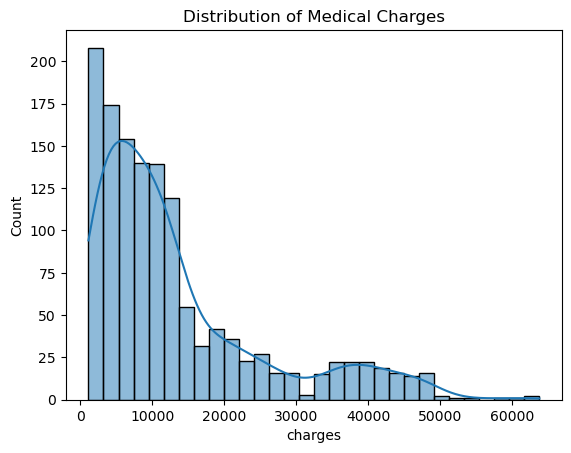

In [30]:
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

#### a. Exploratory Data Analysis (EDA)
##### Boxplot for outliers

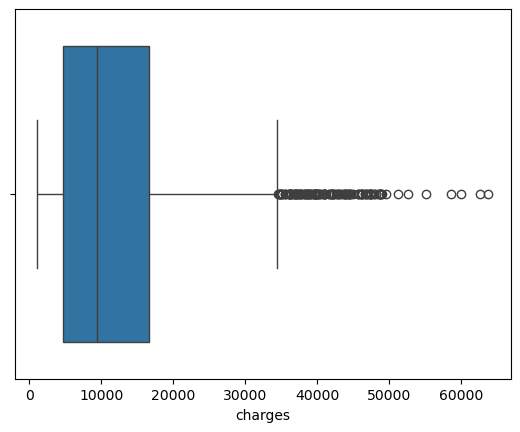

In [31]:
sns.boxplot(x=df['charges'])
plt.show()

#### a. Exploratory Data Analysis (EDA)
##### Correlation heatmap

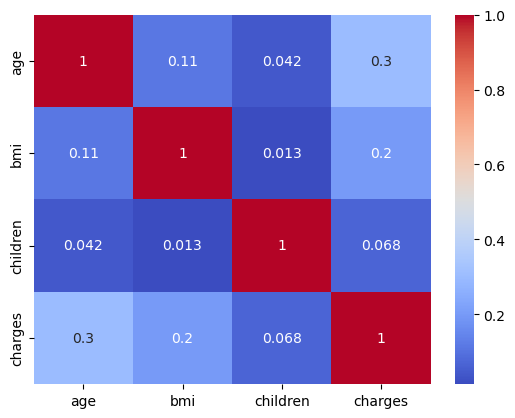

In [32]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

#### a. Exploratory Data Analysis (EDA)
##### Relationship: BMI with Charges

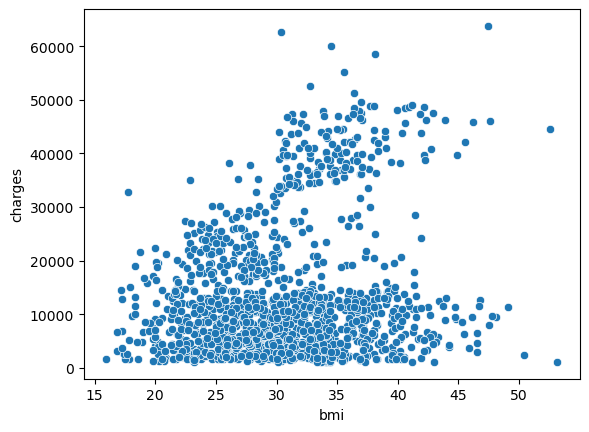

In [33]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.show()

#### a. Exploratory Data Analysis (EDA)
##### Smoking impact: Compare categorical variables using box plots (smoker vs charges)

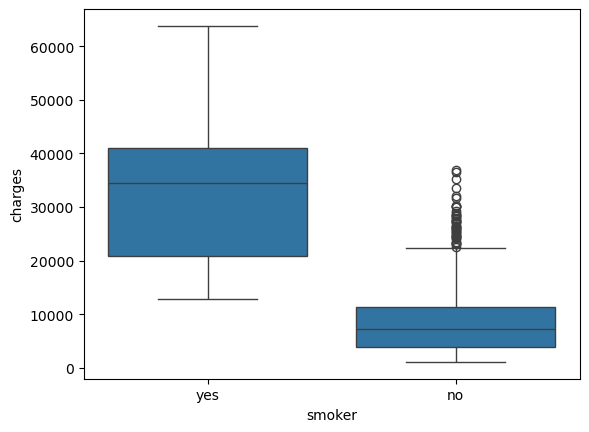

In [34]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

#### a. Exploratory Data Analysis (EDA)
##### Relationship with target (scatter plots)

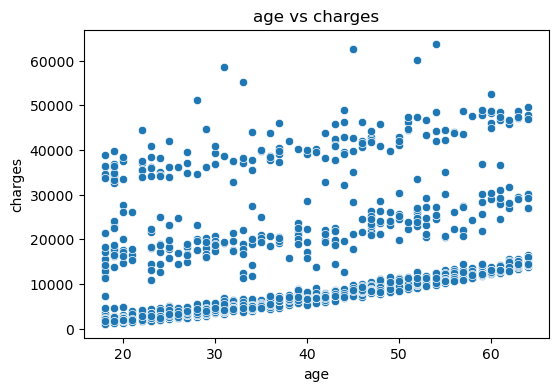

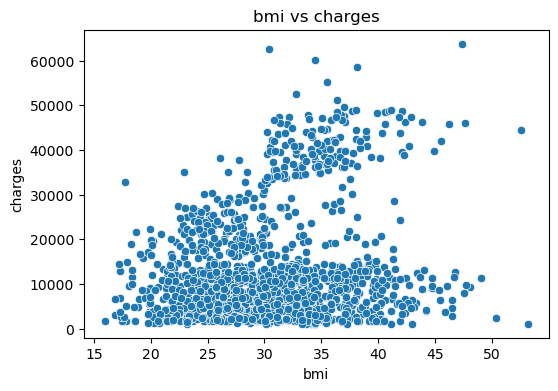

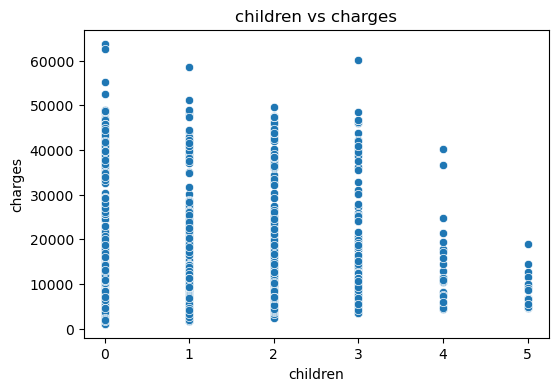

In [35]:
# Scatter plots for numerical variables vs charges
numerical_cols = ['age', 'bmi', 'children']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=col, y='charges', data=df)
    plt.title(f'{col} vs charges')
    plt.xlabel(col)
    plt.ylabel('charges')
    plt.show()

#### b. Feature selection
##### Methods for the linear regression: 
- Encode categorical variables
- One-hot encoding for region

#### b. Feature selection
##### Step : Encode categorical variables

In [36]:
# Sex will be binary (0/1)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
# Smoker will be binary (0/1)
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
# Region will be one-hot encoding
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)
# View first few rows
print(df.head())

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    1  27.900         0       1  16884.92400                 0   
1   18    0  33.770         1       0   1725.55230                 0   
2   28    0  33.000         3       0   4449.46200                 0   
3   33    0  22.705         0       0  21984.47061                 1   
4   32    0  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


#### b. Feature selection
##### Step: correlation matrix to identify the strongest predictors amongst our variables

Correlation with medical charges:
charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
region_northwest   -0.039905
region_southwest   -0.043210
sex                -0.057292
Name: charges, dtype: float64


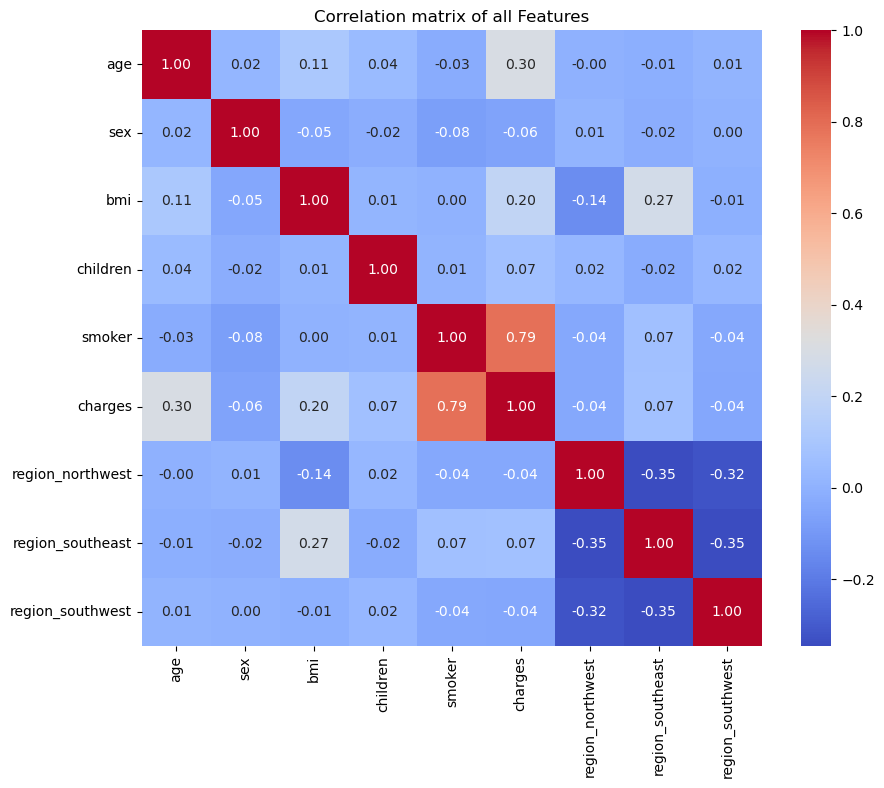

In [37]:
corr_matrix = df.corr()

# correlation with target variable 'charges'
print("Correlation with medical charges:")
print(corr_matrix['charges'].sort_values(ascending=False))

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation matrix of all Features')
plt.show()

#### b. Feature selection
##### Step : statistical methods such as p-values to see feature significance amongst the variables

In [39]:

import statsmodels.api as sm

# Defining predictors (X) and target (y)
X = df.drop('charges', axis=1)
y = df['charges']

# Adding a constant term for the intercept
X = sm.add_constant(X)

# Fitting full OLS model to check p-values
x_y_model = sm.OLS(y, X).fit()
print("Full model summary:\n")
print(x_y_model.summary())

Full model summary:

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:13:39   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1

#### b. Feature selection
##### Step : Backward elimination to remove any irrelevant variables amongst the variables

In [40]:
def backward_elimination(data, target, sl=0.05):
    features = data.columns.tolist()
    while True:
        X_with_const = sm.add_constant(data[features])
        model = sm.OLS(target, X_with_const).fit()
        p_values = model.pvalues.iloc[1:]  # exclude intercept
        max_p = p_values.max()
        if max_p > sl:
            removed_feature = p_values.idxmax()
            features.remove(removed_feature)
            print(f"Removed {removed_feature} (p={max_p:.4f})")
        else:
            break
    return features, model

selected_features, fin_model = backward_elimination(X.drop('const', axis=1), y)

print("\nThe backward elimination final values:")
print(selected_features)

print("\nModel summary:")
print(fin_model.summary())

Removed sex (p=0.6933)
Removed region_northwest (p=0.4596)
Removed region_southwest (p=0.0587)
Removed region_southeast (p=0.1363)

The backward elimination final values:
['age', 'bmi', 'children', 'smoker']

Model summary:
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     998.1
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:13:52   Log-Likelihood:                -13551.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1333   BIC:                         2.714e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                            

##### c. Model Training

The model is Multiple Linear Regression
- Will split the dataset into training and testing sets using the 80/20 split logic
- Wil use Linear Regression from Scikit-learn (LinearRegression() from sklearn)
- And apply default hyperparameters initially
- And will optionally apply feature scaling if required


###### c. Import Machine learning libraries

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

###### c. split the dataset into training and testing sets using the 80/20 split logic

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

###### c. Create model use Linear Regression from Scikit-learn (LinearRegression() from sklearn)

In [43]:
model = LinearRegression()

###### c. Train model

In [45]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


###### c. Predictions

In [46]:
y_pred = model.predict(X_test)

#### 4. Model Evaluation
#####  Import more Machine learning libraries

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

###### a. The metrics used for evaluation are
- R² (coefficient of determination) helps to check goodness of fit
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)


In [48]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4181.194473753647
MSE: 33596915.85136145
RMSE: 5796.284659276273
R2 Score: 0.7835929767120724


##### 5. Model Improvement
###### Improvement 1: Log transformation (handles skewness)
###### Improvement 2: Polynomial term (captures curves)
###### Improvement 3: Interaction term (captures combined effects)

In [49]:
# -----------------------------
# 1. Improvements
# -----------------------------

# Improvement 1 Log transform target (handles skewness)
y = np.log(df['charges'])

# Improvement 2 Add polynomial term (curve)
df['bmi_sqrd'] = df['bmi'] ** 2

# Improvement 3 Add interaction term (combined effect)
df['bmi_smkr'] = df['bmi'] * df['smoker']

# Define the predictors
X = df[['age', 'bmi', 'bmi_sqrd', 'children', 'smoker', 'bmi_smkr']]


##### 5. Model Improvement
###### After improvements retrain the model 

In [50]:
# ---------------------------------------------------------
# 2. Train-test split 80/20 since new features are added
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Train Linear Regression
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# 4. Predictions
# -----------------------------
y_prd_log = model.predict(X_test)

# Convert back to original scale
y_prd = np.exp(y_prd_log)
y_test_actual = np.exp(y_test)

##### 5. Model Improvement
######  reevaluate the model¶

In [51]:
mae = mean_absolute_error(y_test_actual, y_pred)
mse = mean_squared_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)

print("Improved Model Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Improved Model Performance:
MAE: 4181.194473753646
MSE: 33596915.85136146
RMSE: 5796.2846592762735
R2 Score: 0.7835929767120723
